# 1. Quickstart: the 4-DOF testbed

The canonical example of the paper. A serial chain of four masses is split into two
2-DOF subsystems. Each subsystem runs its own unscented Kalman filter (UKF), the two
exchange the interface force by **Jacobi message passing**, and subsystem `S2`
estimates the unknown stiffness `k4` from a single boundary accelerometer.

Install with all optional dependencies:

```bash
pip install "pci-inference[all]"
```

In [1]:
import pci

## The physical system and its synthetic data

`MassSpringChain` is the built-in model: masses in a row, spring `i` connects DOF `i-1`
(0 is the ground) to DOF `i`. We simulate the *monolithic* chain under white-noise
forces to obtain the ground truth, then read two noisy accelerometers from it.

In [2]:
chain = pci.MassSpringChain.uniform(4, mass=500.0, k=50_000.0, c=300.0)
dt, T = 1e-3, 5.0
loads = {d: {"type": "random", "std": 400.0, "seed": d} for d in range(1, 5)}  # a force on every mass
truth = chain.simulate(loads, dt=dt, T=T, x0={"x1": 0.01, "v1": 0.01})
data = chain.measure(truth, ["a1", "a4"], noise_std=1e-3, seed=123)
chain.parameters

{'m1': 500.0,
 'm2': 500.0,
 'm3': 500.0,
 'm4': 500.0,
 'k1': 50000.0,
 'c1': 300.0,
 'k2': 50000.0,
 'c2': 300.0,
 'k3': 50000.0,
 'c3': 300.0,
 'k4': 50000.0,
 'c4': 300.0}

## Decompose into subsystems

`decompose` turns a partition of the DOFs into a `System`: one `Subsystem` per group,
a spring-damper `Interface` for every spring that crosses a partition boundary, and a
message-passing schedule. Everything else (filters, integrators, prior, unknowns) is a
keyword. `k4` is internal to `S2`, so `S2` can estimate it.

With mean-only messages the local filters do not know the error carried by the
incoming interface force, so the measurement covariance is inflated (`r_inflation`);
see the [Concepts](../concepts.md) page.

In [3]:
partition = [[1, 2], [3, 4]]
system = chain.decompose(
    partition,
    unknowns={"k4": {"initial": 30_000.0, "std": 50_000.0}},  # 40 % too low
    sensors=["a1", "a4"],
    noise_std=1e-3,
    filters="ukf",            # or "ckf", "ekf", "kf", or a list/dict per subsystem
    integrator="heun",
    schedule="jacobi",        # or "gauss_seidel", "ab2"
    x0={"x1": 0.01, "v1": 0.01},
    state_var=1e-4,
    process_var=1e-18,
    r_inflation=100.0,        # R = (0.1)^2 as in the paper script, although the sensor noise std is 1e-3
)
print(system.describe())

System 'mass_spring': 2 subsystems, 2 directed interfaces, schedule=Jacobi(iterations=1), messages='mean'
  - S1: states=['x1', 'x2', 'v1', 'v2'], unknowns=[], inputs=['f1', 'f2'], measured=['a1'], filter=ukf, integrator=heun
  - S2: states=['x3', 'x4', 'v3', 'v4'], unknowns=['k4'], inputs=['f3', 'f4'], measured=['a4'], filter=ukf, integrator=heun
  - F_k3: S2['x3', 'v3'] -> S1.f2 (sign -1)
  - F_k3: S1['x2', 'v2'] -> S2.f3 (sign +1)


## Solve the inverse problem

`System.estimate` runs the distributed filter: at every time step each subsystem
predicts with its own dynamics, receives the interface force from its neighbour,
and updates with its own sensors. Passing the truth lets `Results` compute errors.

In [4]:
truth_dict = {**truth.as_dict(), **chain.interface_forces(truth, partition)}
results = system.estimate(data, loads={f"f{d}": v for d, v in loads.items()}, dt=dt, T=T, truth=truth_dict)
print(results.summary(start=1.0))

mode=estimate  schedule=Jacobi(iterations=1)  steps=5000  runtime=1.13s
[S1]
          x1: final= 0.00162137  std= 3.89e-05  rmse= 0.0008366
          x2: final= 0.00285681  std= 6.28e-05  rmse= 0.001535
          v1: final= 0.00110244  std= 0.000234  rmse= 0.003974
          v2: final= 0.028889  std= 0.000378  rmse= 0.006245
[S2]
          x3: final= 0.00349218  std= 0.036  rmse= 0.002047
          x4: final= 0.00259577  std= 0.036  rmse= 0.002337
          v3: final=-0.00157253  std= 0.00707  rmse= 0.00772
          v4: final= 0.0234464  std= 0.00707  rmse= 0.008761
          k4: final= 50156.4  std= 83.5  true= 50000  rmse= 347.1
[messages] F_k3


## Look at the result

`Results` holds the posterior mean and standard deviation of every state and parameter,
the messages exchanged on every interface, and the metrics. Names can be qualified by
subsystem (`"S1.x2"`) or not, when they are unique (`"k4"`).

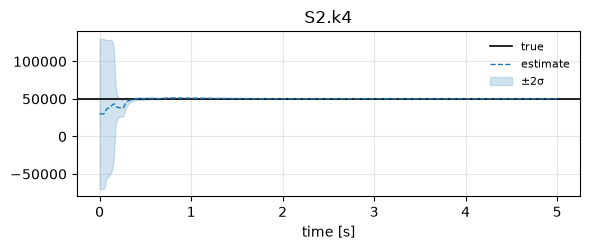

In [5]:
results.plot_parameters();

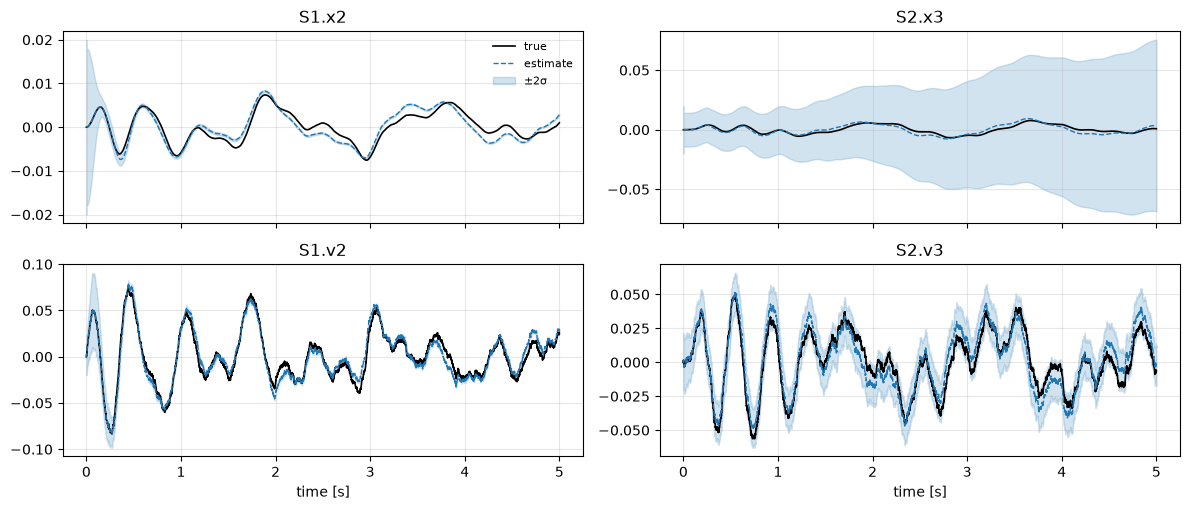

In [6]:
results.plot_states(["S1.x2", "S2.x3", "S1.v2", "S2.v3"]);

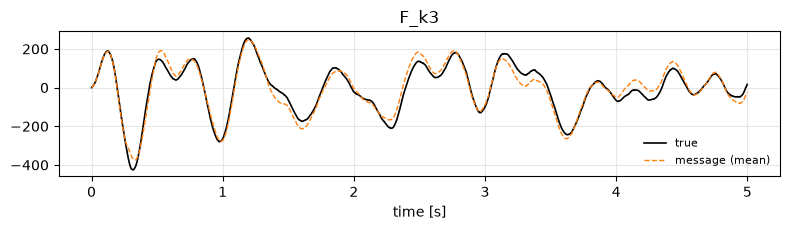

In [7]:
results.plot_messages();

In [8]:
print(f"k4: final = {results.final('k4'):.1f}, true = 50000, posterior std = {results.std('k4')[-1]:.1f}")
results.rmse(["x2", "x3", "k4"], start=1.0)

k4: final = 50156.4, true = 50000, posterior std = 83.5


{'x2': 0.001535150603632427,
 'x3': 0.0020473449321905582,
 'k4': 347.1270099697967}

## The same problem, declaratively

Every tutorial has a YAML twin. `01_four_dof_jacobi_ukf.yaml` describes this problem
(with a few different choices: a CKF and RK4 in `S2`, a harmonic and a step load) and
`pci.solve` runs it without any Python beyond one call. The next tutorial is about
that route.

In [9]:
yaml_results = pci.solve("01_four_dof_jacobi_ukf.yaml")
print(f"YAML twin: k4 final = {yaml_results.final('k4'):.1f}")

YAML twin: k4 final = 49811.7


## Where to go next

- **02 - Problems in YAML**: the declarative route and how to override a configuration.
- **03 - The forward problem**: Jacobi vs Gauss-Seidel vs AB2 against the monolithic model.
- **04 - Custom subsystems**: your own equations, a nonlinear Duffing oscillator.
- **05 - Six DOF, three subsystems**: several unknowns and three different filters.
- **06 - The paper's 6-DOF system**: schedules, filters, integrators and partitions compared.
- **07 - Non-standard subsystems**: Van der Pol and Bouc-Wen written as equation strings.